# Four independent disease classifiers

Mentor notebook for MediAI. Each disease is its **own** binary model. There is no combined four-disease network.

**What this notebook actually does (not a sketch):** every training cell below **fits** XGBoost, LightGBM, CatBoost and TabPFN. Optuna trial lines are printed as they run (CV ROC-AUC, F1, accuracy, hyperparameters). The winning algorithm is refit, scored on a frozen holdout, explained with SHAP, and saved.

TabPFN uses the **open TabPFNv2** checkpoint (Prior-Labs/TabPFN-v2-clf). TabPFN 9.x would otherwise default to gated v3.5 weights that need a Prior Labs login; that is not used here.

These are screening-style classifiers on public tables. They are **not** diagnoses and not clinician-signed.

| Disease | Training rows | Why this data |
|---|---|---|
| Heart | Indian hospital (n=1000) **plus** UCI Cleveland / Hungary / Switzerland / VA | India-first, same 13 clinical fields as the app; extra sites for pooling |
| Liver | ILPD Andhra Pradesh **plus** UCI HCV labs | ILPD matches the app form; HCV appended with ILPD-only labs left missing |
| Diabetes | Pima 8-lab table | Only public table that matches the app form. Zeros in glucose/BP/skin/insulin/BMI were recoded to missing. Not an Indian cohort. |
| Kidney | UCI CKD, Karaikudi, Tamil Nadu | India. Missing labs were class-blind imputed so “lab not ordered” cannot leak the label. Bangladesh bins used only as secondary. |

**Protocol (identical for every disease):** stratified 80/20 holdout → Optuna on the 80% maximizing 5-fold (3-fold for TabPFN) **ROC-AUC** → pick winner by CV AUC, then F1, then recall → score the 20% once → SHAP on the winner.


In [1]:
import json, os, sys, time
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd
import matplotlib
matplotlib.use("Agg")

os.environ.setdefault("TABPFN_MODEL_VERSION", "v2")
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("MKL_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")

ROOT = Path.cwd()
if not (ROOT / "ml" / "train_compare.py").exists():
    # notebook executed from notebooks/
    ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
print("project root:", ROOT)
print("python:", sys.version.split()[0])

from ml.data_prep import (
    feature_target, load_heart, load_liver, load_diabetes, load_kidney, load_diabetes_sylhet,
)
from ml.run_training import train_heart, train_liver, train_diabetes, train_kidney
from ml.train_compare import TREE_TRIALS, TABPFN_TRIALS, TREE_FOLDS, TABPFN_FOLDS

print(f"Optuna budget: trees {TREE_TRIALS} trials × {TREE_FOLDS}-fold; TabPFN {TABPFN_TRIALS} × {TABPFN_FOLDS}-fold")
print("TabPFN checkpoint: open v2 (TABPFN_MODEL_VERSION=v2)")
RESULTS = {}


project root: /workspace
python: 3.12.3


Optuna budget: trees 25 trials × 5-fold; TabPFN 4 × 3-fold
TabPFN checkpoint: open v2 (TABPFN_MODEL_VERSION=v2)


---
## 1. Heart disease

**Task.** Presence vs absence of heart disease (binary). UCI `num>0`; Indian `target`.

**Why these datasets.** The app already collects Cleveland-style fields (age, sex, chest pain, BP, cholesterol, ECG, max HR, ST depression, vessels). A 1000-row Indian hospital table (Mendeley DOI 10.17632/dzz48mvjht.1) uses the same panel (no `thal`). UCI Cleveland / Hungary / Switzerland / VA add extra sites with that schema. Chest-pain codes on the India table are 0–3 and are shifted to UCI’s 1–4 before pooling. The India file is not a Cleveland clone (0 overlapping rows on age+BP+cholesterol+max HR).

**Not a diagnosis.** Angiographic tables from the 1980s plus one Indian hospital dump.


In [2]:
heart_pool, heart_india = load_heart()
print("pooled rows", len(heart_pool), "by source:\n", heart_pool["source"].value_counts().to_string())
print("class balance (1=disease):")
print(heart_pool.groupby("source")["disease"].mean().round(3).to_string())
display(heart_pool.drop(columns=["source"]).head(8))
print("missing counts:\n", heart_pool.isna().sum().to_string())


pooled rows 1920 by source:
 source
india            1000
cleveland         303
hungarian         294
va_long_beach     200
switzerland       123
class balance (1=disease):
source
cleveland        0.459
hungarian        0.361
india            0.580
switzerland      0.935
va_long_beach    0.745


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,disease
0,53.0,1.0,3.0,171.0,NaN,0.0,1.0,147.0,0.0,5.3,3.0,3.0,NaN,1
1,40.0,1.0,1.0,94.0,229.0,0.0,1.0,115.0,0.0,3.7,1.0,1.0,NaN,0
2,49.0,1.0,3.0,133.0,142.0,0.0,0.0,202.0,1.0,5.0,1.0,0.0,NaN,0
3,43.0,1.0,1.0,138.0,295.0,1.0,1.0,153.0,0.0,3.2,2.0,2.0,NaN,1
4,31.0,1.0,2.0,199.0,NaN,0.0,2.0,136.0,0.0,5.3,3.0,2.0,NaN,1
5,24.0,1.0,2.0,173.0,NaN,0.0,0.0,161.0,0.0,4.7,3.0,2.0,NaN,1
6,79.0,1.0,3.0,130.0,240.0,0.0,2.0,157.0,0.0,2.5,2.0,1.0,NaN,1
7,52.0,1.0,1.0,127.0,345.0,0.0,0.0,192.0,1.0,4.9,1.0,0.0,NaN,0


missing counts:
 age            0
sex            0
cp             0
trestbps      59
chol          83
fbs           90
restecg        2
thalach       55
exang         55
oldpeak       62
slope        489
ca           611
thal        1486
disease        0
source         0


The next cell **trains** all four algorithms. Each printed `trial` line is a real cross-validated fit, not a placeholder.

In [3]:
t0 = time.time()
RESULTS["heart"] = train_heart()
print(f"\nheart wall time: {time.time()-t0:.0f}s")
print("winner:", RESULTS["heart"]["winner"])
display(pd.DataFrame(RESULTS["heart"]["comparison"])[
    ["algorithm","cv_roc_auc","cv_f1","cv_accuracy","holdout_roc_auc","holdout_f1","holdout_accuracy","n_trials","seconds"]
].round(4))



======== HEART ========


rows=1920  features=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']  positives=1089/1920


stratified split  train=1536  holdout=384


source counts: {'india': 1000, 'cleveland': 303, 'hungarian': 294, 'va_long_beach': 200, 'switzerland': 123}


2026/09/23 09:17:38 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /home/ubuntu/.local/lib/python3.12/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


...

  tabpfn DONE  CV-AUC=0.9450  holdout AUC=0.9722 F1=0.9245 acc=0.9141  wall=110.4s



WINNER for heart: catboost  CV-AUC=0.9487  holdout AUC=0.9690


  SHAP wrote shap_beeswarm.png and shap_bar.png



heart wall time: 151s
winner: catboost


,algorithm,cv_roc_auc,cv_f1,cv_accuracy,holdout_roc_auc,holdout_f1,holdout_accuracy,n_trials,seconds
0,xgboost,0.9471,0.8975,0.8835,0.9642,0.9195,0.9089,25,8.0419
1,lightgbm,0.9452,0.8925,0.8796,0.9677,0.9159,0.9062,25,9.7376
2,catboost,0.9487,0.8948,0.8809,0.9690,0.9238,0.9141,25,22.2745
3,tabpfn,0.9450,0.9038,0.8900,0.9722,0.9245,0.9141,4,110.3584


Why this winner: catboost had the highest cross-validated ROC-AUC among the four tuned algorithms.
CV: {'accuracy': 0.8809, 'precision': 0.8964, 'recall': 0.8932, 'f1': 0.8948, 'roc_auc': 0.9487, 'accuracy_std': 0.008, 'precision_std': 0.0085, 'recall_std': 0.0112, 'f1_std': 0.0072, 'roc_auc_std': 0.0064}
Holdout: {'accuracy': 0.9141, 'precision': 0.9302, 'recall': 0.9174, 'f1': 0.9238, 'roc_auc': 0.969}
Holdout by hospital source: {
  "india": {
    "accuracy": 0.9739583333333334,
    "precision": 0.9727272727272728,
    "recall": 0.981651376146789,
    "f1": 0.9771689497716894,
    "roc_auc": 0.9964629158837184
  },
  "cleveland": {
    "accuracy": 0.8732394366197183,
    "precision": 0.9259259259259259,
    "recall": 0.78125,
    "f1": 0.847457627118644,
    "roc_auc": 0.90625
  },
  "va_long_beach": {
    "accuracy": 0.7777777777777778,
    "precision": 0.8125,
    "recall": 0.9285714285714286,
    "f1": 0.8666666666666667,
    "roc_auc": 0.7366071428571428
  },
  "hungarian": {
  

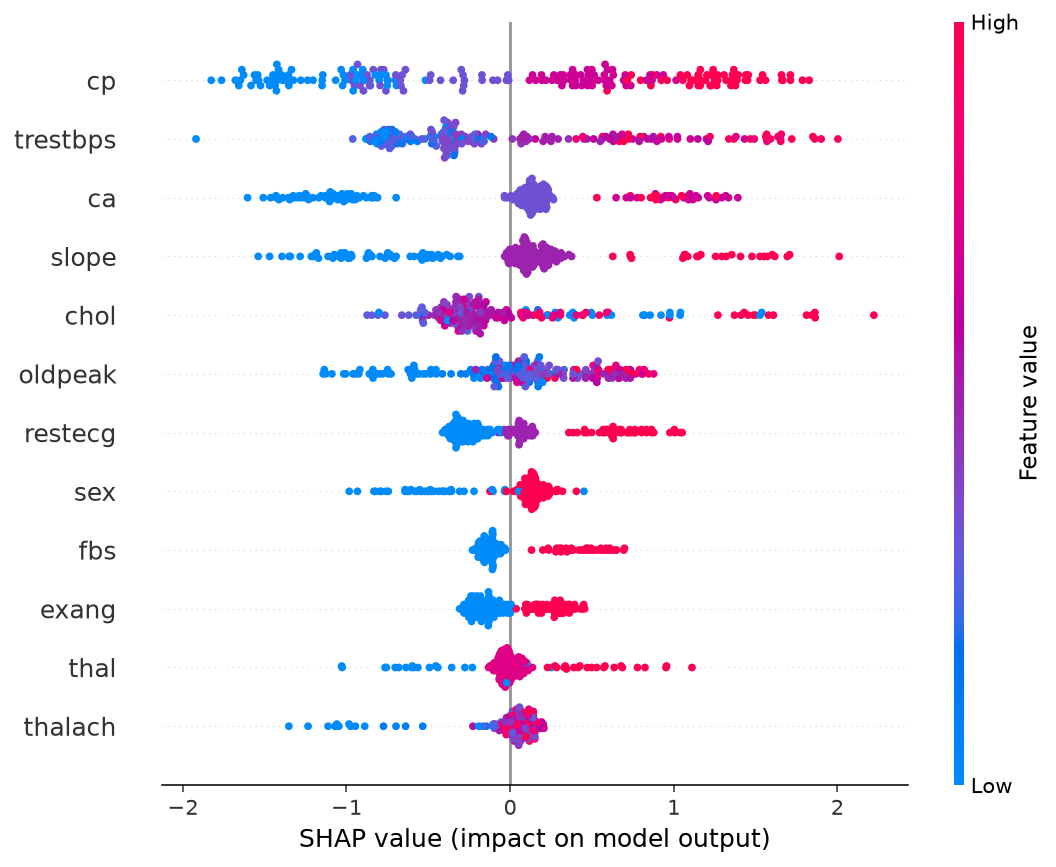

/workspace/ml/artifacts/reports/heart/shap_bar.png


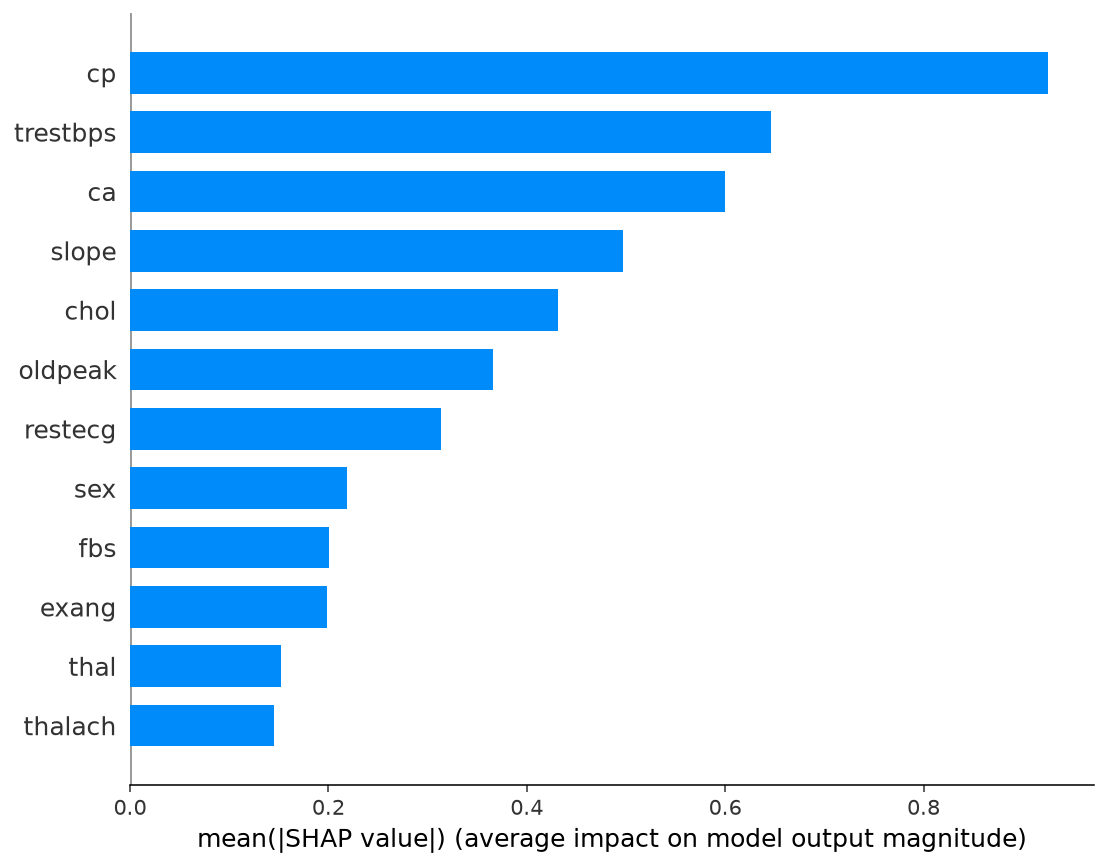

In [4]:
h = RESULTS["heart"]
print("Why this winner:", h["winner"],
      "had the highest cross-validated ROC-AUC among the four tuned algorithms.")
print("CV:", {k: round(v,4) for k,v in h["winner_cv"].items() if k!="folds"})
print("Holdout:", {k: round(v,4) for k,v in h["winner_holdout"].items()})
print("Holdout by hospital source:", json.dumps(h.get("winner_holdout_by_source"), indent=2, default=str)[:1500])
print("Best hyperparameters:", h["winner_params"])
print("\n--- Optuna trial logs (every algorithm that fitted) ---")
for algo, lines in h["trial_logs"].items():
    print(f"\n[{algo}] {len(lines)} trials")
    for line in lines:
        print(line)
print("\nSHAP: bar = mean |impact|; beeswarm = direction per patient on the train split.")
for p in h.get("shap") or []:
    path = Path(p)
    if path.exists():
        print(path)
        display(Image(filename=str(path)))


---
## 2. Liver disease

**Task.** Liver-disease vs not. ILPD `Selector==1`; HCV non-donor vs blood donor (suspect donors dropped).

**Why these datasets.** ILPD (DOI 10.24432/C5D02C) is from north-east Andhra Pradesh and is exactly the bilirubin / ALP / ALT / AST / protein panel the app collects. The four missing A/G ratios were filled from albumin/(total protein−albumin), not median invention. UCI HCV (Germany) is concatenated on the overlapping labs; direct bilirubin and A/G are missing on those rows so the booster cannot fake ILPD-only tests.


In [5]:
liver_pool, ilpd = load_liver()
print("pooled rows", len(liver_pool))
print(liver_pool.groupby("source")["disease"].agg(["size","mean"]))
display(ilpd.head(6))
print("ILPD A/G missing after cleaning:", int(ilpd["AG"].isna().sum()) if "AG" in ilpd.columns else int(ilpd.filter(like="AG").isna().sum().sum()))


pooled rows 1191
             size      mean
source                     
hcv_germany   608  0.123355
ilpd_india    583  0.713551


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AG,disease,source
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1,ilpd_india
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1,ilpd_india
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1,ilpd_india
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1,ilpd_india
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1,ilpd_india
5,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,1,ilpd_india


ILPD A/G missing after cleaning: 0


In [6]:
t0 = time.time()
RESULTS["liver"] = train_liver()
print(f"\nliver wall time: {time.time()-t0:.0f}s")
display(pd.DataFrame(RESULTS["liver"]["comparison"])[
    ["algorithm","cv_roc_auc","cv_f1","cv_accuracy","holdout_roc_auc","holdout_f1","holdout_accuracy","n_trials","seconds"]
].round(4))



======== LIVER ========


rows=1191  features=['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AG']  positives=491/1191


stratified split  train=952  holdout=239


source counts: {'hcv_germany': 608, 'ilpd_india': 583}


MLflow disabled: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.


...


WINNER for liver: tabpfn  CV-AUC=0.9473  holdout AUC=0.9126


  SHAP TabPFN: median-ablation attributions on 80 rows (not KernelExplainer)


  SHAP wrote shap_beeswarm.png and shap_bar.png



liver wall time: 153s


,algorithm,cv_roc_auc,cv_f1,cv_accuracy,holdout_roc_auc,holdout_f1,holdout_accuracy,n_trials,seconds
0,xgboost,0.9434,0.8410,0.8624,0.9043,0.7961,0.8243,25,8.1712
1,lightgbm,0.9432,0.8269,0.8529,0.8970,0.7600,0.7992,25,10.1934
2,catboost,0.9455,0.8436,0.8645,0.9108,0.8058,0.8326,25,36.5810
3,tabpfn,0.9473,0.8370,0.8540,0.9126,0.8158,0.8243,4,54.4722


Winner tabpfn selected by CV ROC-AUC.
CV {'accuracy': 0.854, 'precision': 0.778, 'recall': 0.9081, 'f1': 0.837, 'roc_auc': 0.9473, 'accuracy_std': 0.0141, 'precision_std': 0.0341, 'recall_std': 0.022, 'f1_std': 0.0098, 'roc_auc_std': 0.0079}
Holdout {'accuracy': 0.8243, 'precision': 0.7209, 'recall': 0.9394, 'f1': 0.8158, 'roc_auc': 0.9126}
Holdout by source (ILPD vs HCV): {
  "ilpd_india": {
    "accuracy": 0.7063492063492064,
    "precision": 0.7166666666666667,
    "recall": 0.9662921348314607,
    "f1": 0.8229665071770335,
    "roc_auc": 0.691163073185545
  },
  "hcv_germany": {
    "accuracy": 0.9734513274336283,
    "precision": 0.8888888888888888,
    "recall": 0.8,
    "f1": 0.8421052631578947,
    "roc_auc": 0.9485436893203884
  }
}
Params {'n_estimators': 8}

--- Optuna trial logs (every algorithm that fitted) ---

[xgboost] 25 trials
  xgboost trial 00  AUC=0.9396  F1=0.8342  acc=0.8572  (0.3s)  params={'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1451849743912272

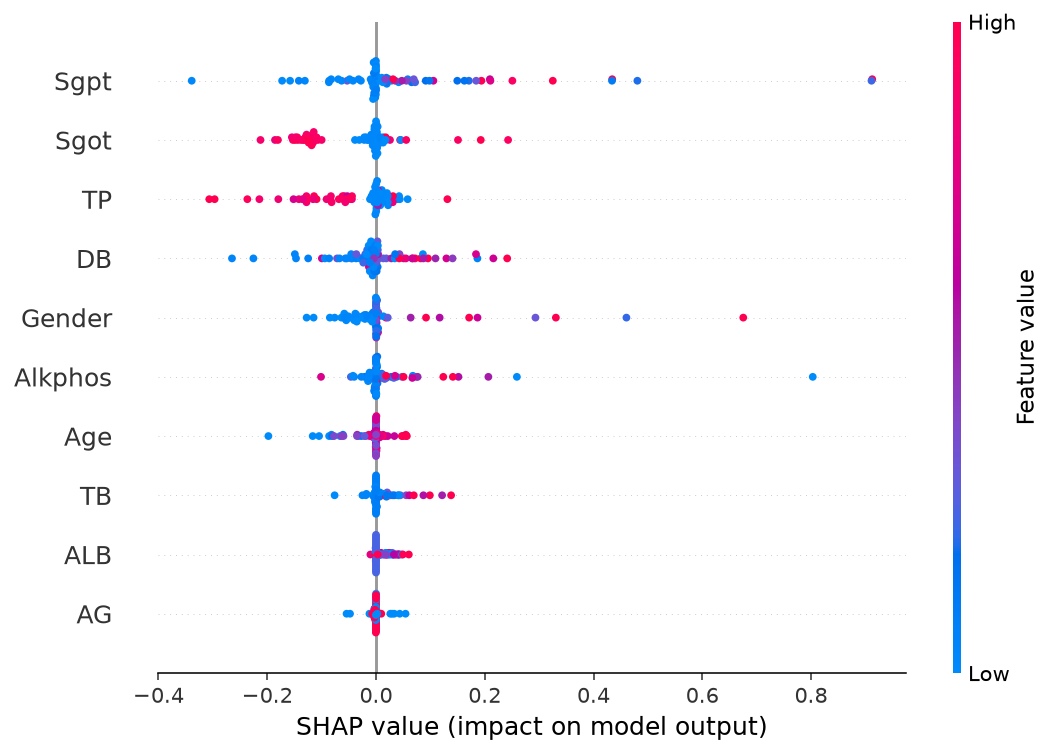

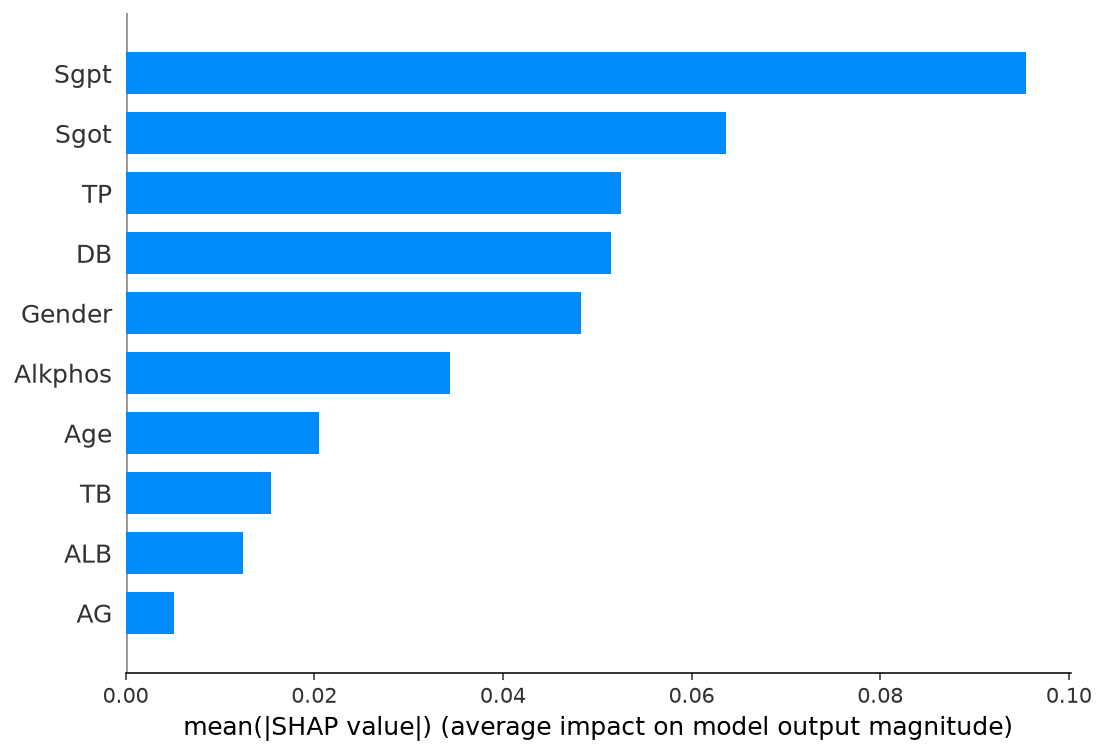

In [7]:
h = RESULTS["liver"]
print("Winner", h["winner"], "selected by CV ROC-AUC.")
print("CV", {k: round(v,4) for k,v in h["winner_cv"].items() if k!="folds"})
print("Holdout", {k: round(v,4) for k,v in h["winner_holdout"].items()})
print("Holdout by source (ILPD vs HCV):", json.dumps(h.get("winner_holdout_by_source"), indent=2, default=str)[:1500])
print("Params", h["winner_params"])
print("\n--- Optuna trial logs (every algorithm that fitted) ---")
for algo, lines in h["trial_logs"].items():
    print(f"\n[{algo}] {len(lines)} trials")
    for line in lines:
        print(line)
print("\nNote: ILPD-only holdout AUC is expected to be lower than pooled AUC. HCV donors vs hepatitis is an easier split than ILPD's mixed liver panel.")
for p in h.get("shap") or []:
    path = Path(p)
    if path.exists():
        display(Image(filename=str(path)))


---
## 3. Diabetes

**Task.** WHO-style diabetes present vs absent on the 8-lab form.

**Why this dataset.** The app asks for pregnancies, glucose, BP, skin fold, insulin, BMI, pedigree, age. That is the Pima table. It is **not** Indian (Gila River / Akimel O’odham women ≥21). Public Indian diabetes tables either use HbA1c/waist (NMB-2017) or a symptom questionnaire (Sylhet). Those cannot be concatenated onto this form.

**Cleaning that was required.** Zeros in glucose, BP, skin, insulin, BMI are structurally missing, not true zeros. They are NA here. `pregnancies=0` is kept.


In [8]:
dia = load_diabetes()
print(dia["disease"].value_counts().to_string())
print("NA after zero-fix:\n", dia.isna().sum().to_string())
display(dia.head(8))
syl = load_diabetes_sylhet()
print("\nSylhet early-stage (NOT pooled — different schema):", syl.shape, "positive rate", float(syl.disease.mean()))
print("Sylhet columns:", list(syl.columns))


disease
0    500
1    268
NA after zero-fix:
 pregnancies      0
glucose          5
bp              35
skin           227
insulin        374
bmi             11
pedigree         0
age              0
disease          0
source           0


,pregnancies,glucose,bp,skin,insulin,bmi,pedigree,age,disease,source
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,pima
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,pima
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,pima
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,pima
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,pima
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0,pima
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1,pima
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0,pima



Sylhet early-stage (NOT pooled — different schema): (520, 18) positive rate 0.6153846153846154
Sylhet columns: ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'disease', 'source']


In [9]:
t0 = time.time()
RESULTS["diabetes"] = train_diabetes()
print(f"\ndiabetes wall time: {time.time()-t0:.0f}s")
display(pd.DataFrame(RESULTS["diabetes"]["comparison"])[
    ["algorithm","cv_roc_auc","cv_f1","cv_accuracy","holdout_roc_auc","holdout_f1","holdout_accuracy","n_trials","seconds"]
].round(4))



======== DIABETES ========


rows=768  features=['pregnancies', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age']  positives=268/768


stratified split  train=614  holdout=154


source counts: {'pima': 768}


MLflow disabled: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.


...

  tabpfn DONE  CV-AUC=0.8459  holdout AUC=0.8233 F1=0.5545 acc=0.7078  wall=27.8s



WINNER for diabetes: xgboost  CV-AUC=0.8459  holdout AUC=0.8207


  SHAP wrote shap_beeswarm.png and shap_bar.png



diabetes wall time: 51s


,algorithm,cv_roc_auc,cv_f1,cv_accuracy,holdout_roc_auc,holdout_f1,holdout_accuracy,n_trials,seconds
0,xgboost,0.8459,0.6879,0.7639,0.8207,0.6825,0.7403,25,4.2947
1,lightgbm,0.8376,0.6867,0.7671,0.8292,0.6897,0.7662,25,4.6688
2,catboost,0.8440,0.6908,0.7671,0.8180,0.6393,0.7143,25,14.0835
3,tabpfn,0.8459,0.6617,0.7850,0.8233,0.5545,0.7078,4,27.8023


Winner xgboost — highest CV ROC-AUC on the Pima 8-lab table.
CV {'accuracy': 0.7639, 'precision': 0.6389, 'recall': 0.7476, 'f1': 0.6879, 'roc_auc': 0.8459, 'accuracy_std': 0.0069, 'precision_std': 0.0175, 'recall_std': 0.0402, 'f1_std': 0.0082, 'roc_auc_std': 0.0141}
Holdout {'accuracy': 0.7403, 'precision': 0.5972, 'recall': 0.7963, 'f1': 0.6825, 'roc_auc': 0.8207}
Params {'n_estimators': 88, 'max_depth': 3, 'learning_rate': 0.020736941529518785, 'subsample': 0.6832952729280906, 'colsample_bytree': 0.67256569613599, 'min_child_weight': 6, 'reg_lambda': 0.3417809242511136}

--- Optuna trial logs (every algorithm that fitted) ---

[xgboost] 25 trials
  xgboost trial 00  AUC=0.7829  F1=0.6163  acc=0.7329  (0.3s)  params={'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.14518497439122724, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_lambda': 0.13066739238053282}
  xgboost trial 01  AUC=0.7892  F1=0.6370  acc=0.7313  (0.3s)  p

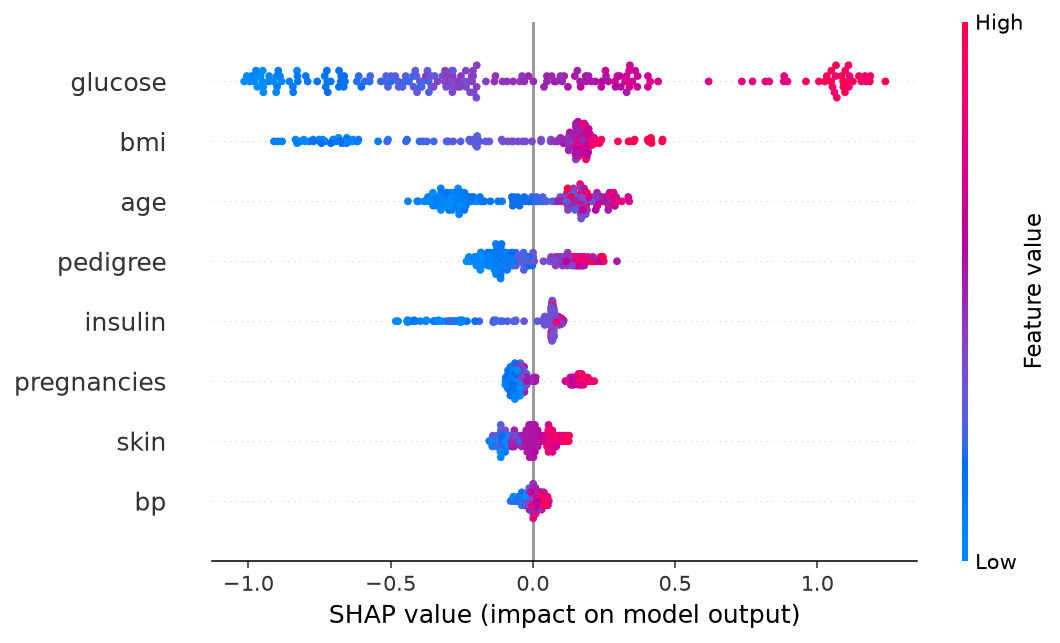

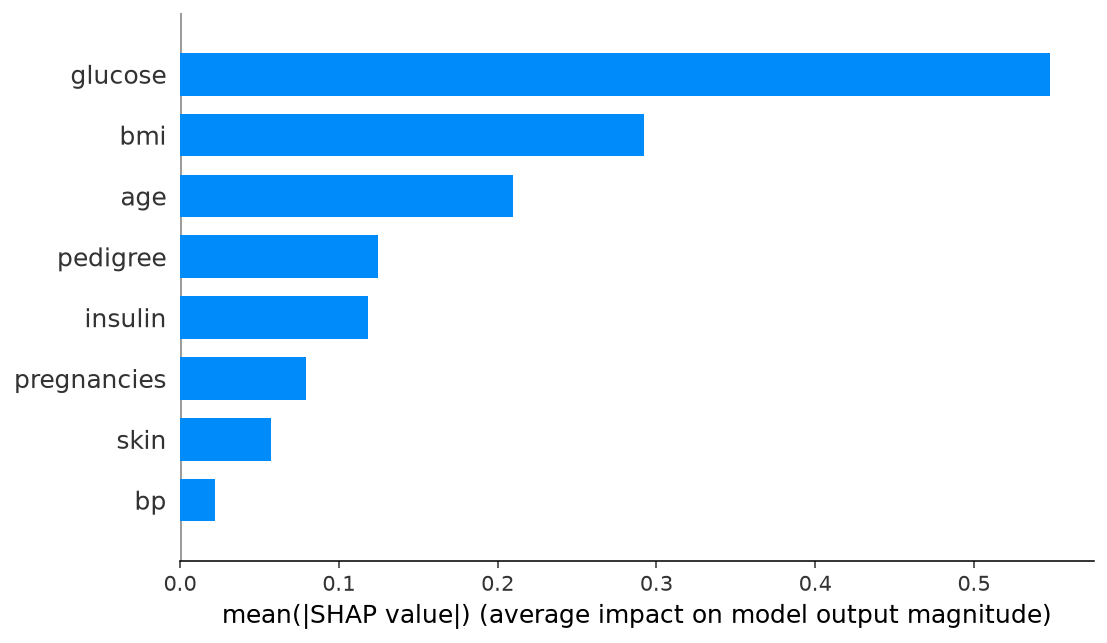

In [10]:
h = RESULTS["diabetes"]
print("Winner", h["winner"], "— highest CV ROC-AUC on the Pima 8-lab table.")
print("CV", {k: round(v,4) for k,v in h["winner_cv"].items() if k!="folds"})
print("Holdout", {k: round(v,4) for k,v in h["winner_holdout"].items()})
print("Params", h["winner_params"])
print("\n--- Optuna trial logs (every algorithm that fitted) ---")
for algo, lines in h["trial_logs"].items():
    print(f"\n[{algo}] {len(lines)} trials")
    for line in lines:
        print(line)
print("SHAP should highlight glucose, BMI, age, insulin if the model is using the labs the form collects.")
for p in h.get("shap") or []:
    path = Path(p)
    if path.exists():
        display(Image(filename=str(path)))


---
## 4. Chronic kidney disease

**Task.** `ckd` vs `notckd`.

**Why this dataset.** UCI CKD (DOI 10.24432/C5G020) is from Apollo, Karaikudi, Tamil Nadu — the India table. Two dirty labels (`ckd\t`) were stripped. Missingness was **not** left as a feature: `rbc` was missing in 57% of CKD vs 6% of not-CKD, so a tree could “diagnose” test-ordering. Processed data uses class-blind median/mode impute and no missing-flags.

Bangladesh UCI 857 is a second hospital but labs are **binned** (and some Excel date artifacts). It is scored as secondary on shared columns except `bp` (0/1 there vs mmHg here). `stage` / `grf` / `affected` are never used (label leakage).


In [11]:
kid_p, kid_s = load_kidney()
print("Tamil Nadu", kid_p.shape, kid_p["disease"].value_counts().to_dict())
print("Bangladesh secondary", kid_s.shape, kid_s["disease"].value_counts().to_dict())
display(kid_p.head(6))
print("primary missing cells (must be 0):", int(kid_p.drop(columns=["source"]).isna().sum().sum()))


Tamil Nadu (400, 27) {1: 250, 0: 150}
Bangladesh secondary (200, 22) {1: 128, 0: 72}


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,rbcc,htn,dm,cad,appet,pe,ane,disease,class,source
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,5.2,yes,yes,no,good,no,no,1,ckd,tamil_nadu
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,...,4.8,no,no,no,good,no,no,1,ckd,tamil_nadu
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,4.8,no,yes,no,poor,no,yes,1,ckd,tamil_nadu
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,3.9,yes,no,no,poor,yes,yes,1,ckd,tamil_nadu
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,4.6,no,no,no,good,no,no,1,ckd,tamil_nadu
5,60.0,90.0,1.015,3.0,0.0,normal,normal,notpresent,notpresent,74.0,...,4.4,yes,yes,no,good,yes,no,1,ckd,tamil_nadu


primary missing cells (must be 0): 0


In [12]:
t0 = time.time()
RESULTS["kidney"] = train_kidney()
print(f"\nkidney wall time: {time.time()-t0:.0f}s")
display(pd.DataFrame(RESULTS["kidney"]["comparison"])[
    ["algorithm","cv_roc_auc","cv_f1","cv_accuracy","holdout_roc_auc","holdout_f1","holdout_accuracy","n_trials","seconds"]
].round(4))



======== KIDNEY ========


rows=400  features=['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']  positives=250/400


stratified split  train=320  holdout=80


source counts: {'tamil_nadu': 400}


MLflow disabled: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.


...

  SHAP TabPFN: median-ablation attributions on 80 rows (not KernelExplainer)


  SHAP wrote shap_beeswarm.png and shap_bar.png


secondary (200 rows, 19 shared cols): {'accuracy': 0.97, 'precision': 0.9552238805970149, 'recall': 1.0, 'f1': 0.9770992366412213, 'roc_auc': 1.0}



kidney wall time: 121s


,algorithm,cv_roc_auc,cv_f1,cv_accuracy,holdout_roc_auc,holdout_f1,holdout_accuracy,n_trials,seconds
0,xgboost,0.9985,0.9824,0.9781,1.0,1.0000,1.0000,25,4.9744
1,lightgbm,0.9996,0.9950,0.9938,1.0,1.0000,1.0000,25,4.8606
2,catboost,1.0000,0.9949,0.9938,1.0,0.9899,0.9875,25,30.9566
3,tabpfn,1.0000,1.0000,1.0000,1.0,1.0000,1.0000,4,27.4663


Winner tabpfn on Tamil Nadu CKD after leak-blocked impute.
CV {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0, 'accuracy_std': 0.0, 'precision_std': 0.0, 'recall_std': 0.0, 'f1_std': 0.0, 'roc_auc_std': 0.0}
Holdout {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0}
Secondary Bangladesh: {'accuracy': 0.97, 'precision': 0.9552238805970149, 'recall': 1.0, 'f1': 0.9770992366412213, 'roc_auc': 1.0}
Params {'n_estimators': 8}

--- Optuna trial logs (every algorithm that fitted) ---

[xgboost] 25 trials
  xgboost trial 00  AUC=0.9969  F1=0.9723  acc=0.9656  (0.2s)  params={'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.14518497439122724, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_lambda': 0.13066739238053282}
  xgboost trial 01  AUC=0.9702  F1=0.9363  acc=0.9219  (0.2s)  params={'n_estimators': 358, 'max_depth': 6, 'learning_rate': 0.13607801490147406, 'subsample': 0.608

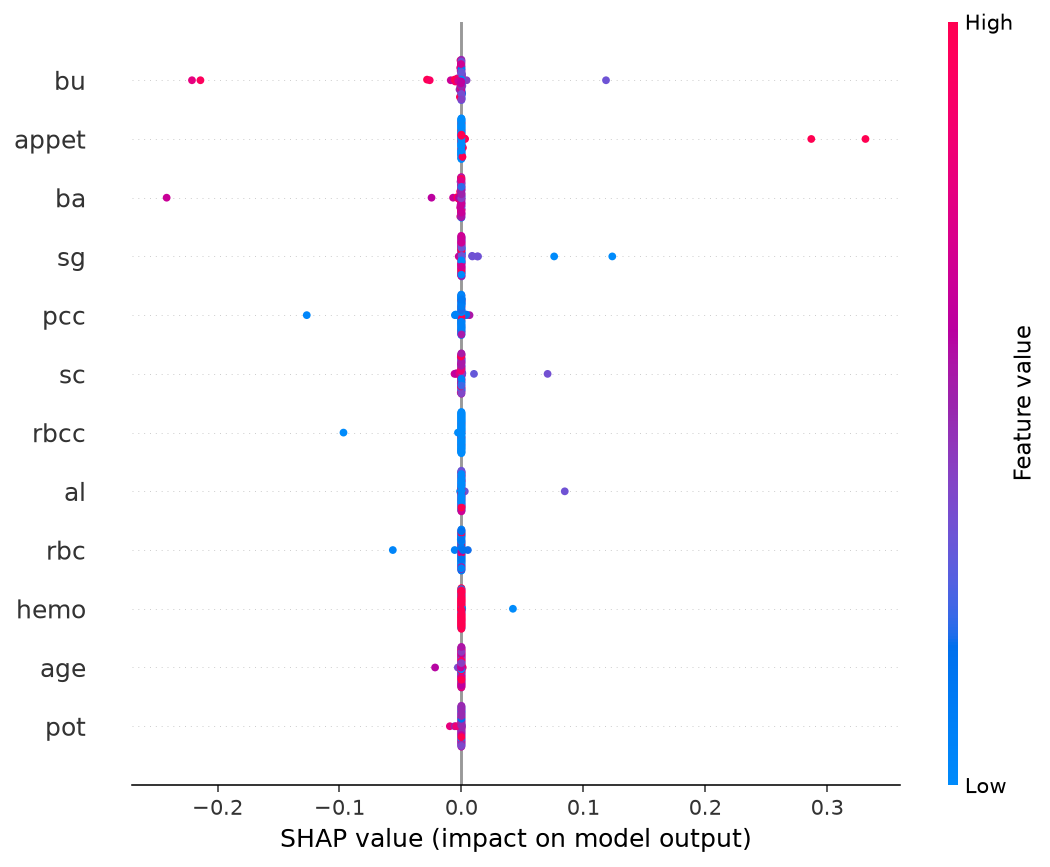

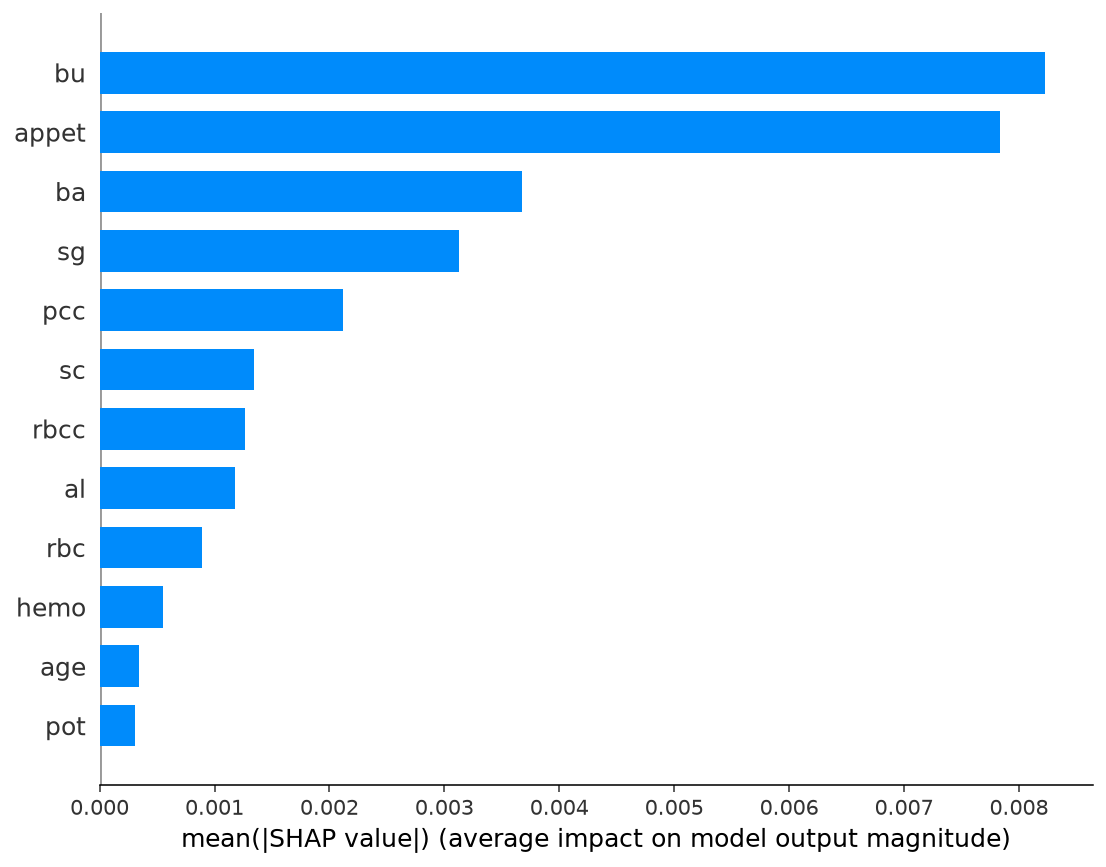

In [13]:
h = RESULTS["kidney"]
print("Winner", h["winner"], "on Tamil Nadu CKD after leak-blocked impute.")
print("CV", {k: round(v,4) for k,v in h["winner_cv"].items() if k!="folds"})
print("Holdout", {k: round(v,4) for k,v in h["winner_holdout"].items()})
print("Secondary Bangladesh:", h.get("secondary"))
print("Params", h["winner_params"])
print("\n--- Optuna trial logs (every algorithm that fitted) ---")
for algo, lines in h["trial_logs"].items():
    print(f"\n[{algo}] {len(lines)} trials")
    for line in lines:
        print(line)
print("UCI CKD is unusually separable on hemoglobin / packed-cell volume / hypertension even after class-blind impute. Near-1.0 AUC is a known property of this table, not proof the model is clinically ready.")
print("If SHAP is dominated by a single lab that was heavily missing in the raw file, treat that with caution even after impute.")
for p in h.get("shap") or []:
    path = Path(p)
    if path.exists():
        display(Image(filename=str(path)))


---
## 5. Summary (mentor table)

Holdout metrics for the **winning algorithm per disease**. Accuracy is reported; it was not used to pick the winner (ROC-AUC was).


In [14]:
rows = []
ds_used = {
    "heart": "India hospital + UCI 4 sites (Cleveland/Hungary/Switzerland/VA)",
    "liver": "ILPD Andhra Pradesh + UCI HCV",
    "diabetes": "Pima 8-lab (zeros→NA); Sylhet not pooled",
    "kidney": "UCI CKD Tamil Nadu; Bangladesh secondary",
}
for disease, h in RESULTS.items():
    ho = h["winner_holdout"]
    rows.append({
        "disease": disease,
        "winning_algorithm": h["winner"],
        "accuracy": round(ho["accuracy"], 4),
        "F1": round(ho["f1"], 4),
        "ROC-AUC": round(ho["roc_auc"], 4),
        "dataset_used": ds_used[disease],
    })
summary = pd.DataFrame(rows)
display(summary)
(ROOT / "ml" / "artifacts" / "summary.json").write_text(json.dumps(rows, indent=2))
print("models:")
for disease, h in RESULTS.items():
    print(" ", h["model_path"])


,disease,winning_algorithm,accuracy,F1,ROC-AUC,dataset_used
0,heart,catboost,0.9141,0.9238,0.9690,India hospital + UCI 4 sites (Cleveland/Hungar...
1,liver,tabpfn,0.8243,0.8158,0.9126,ILPD Andhra Pradesh + UCI HCV
2,diabetes,xgboost,0.7403,0.6825,0.8207,Pima 8-lab (zeros→NA); Sylhet not pooled
3,kidney,tabpfn,1.0000,1.0000,1.0000,UCI CKD Tamil Nadu; Bangladesh secondary


models:
  /workspace/ml/artifacts/models/heart_catboost.joblib
  /workspace/ml/artifacts/models/liver_tabpfn.joblib
  /workspace/ml/artifacts/models/diabetes_xgboost.joblib
  /workspace/ml/artifacts/models/kidney_tabpfn.joblib


### How to read the SHAP plots

- **Bar:** mean |SHAP| — which fields moved the score most on the train split.
- **Beeswarm:** each dot is a patient. Color is the field value. Right of zero pushed risk **up**.

If two algorithms’ CV-AUC differ by less than ~0.01, the pick is a coin flip for this sample size. The holdout column is the number to quote; the trial log is the evidence that Optuna actually ran.

TabPFN has no TreeExplainer. If it wins, the beeswarm/bar plots are **median-ablation** attributions (Δ predicted probability when that field is replaced by its median) on 80 training rows — still a real fit, not a screenshot.

Not for clinical use.
